In [1]:
import os
import json
import pandas as pd
from PIL import Image
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm
import matplotlib.pyplot as plt
#from diffusers import StableDiffusionPipeline
from sklearn.metrics import pairwise_distances


C:\Users\ASUS\anaconda3\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
pip install diffusers transformers torch torchvision matplotlib pandas scikit-image


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import json
import pandas as pd
import os
from PIL import Image
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Load JSON file
json_path = r"C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos.json"
dataset_path = r"C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos"

# Load JSONL file (each line is a separate JSON object)
data = []
with open(json_path, 'r', encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line.strip()))  # Load each line separately

# Convert to DataFrame
df = pd.DataFrame(data)

# Sample 10,000 entries from the dataset
df_sample = df.sample(n=10000, random_state=42)

# Preview the sample data
print(df_sample.head())


                      photo_id             business_id              caption  \
32568   k_PSngRS22mSA1MypwrjPg  DzzVSYXadZ1_XgfGz_Loyw  Chocolate Croissant   
174911  D_94KivwVgitkzFIgE_KcQ  Xdzir62WKlSzeu4PMQtlBA                        
132444  Hf39P7_G_eRCqfVwvMDV6g  z0HzwNBmx_BgdiYI4hLk3g    Happy Anniversary   
46744   agxl4sABeRXwjLL506KMrQ  HzRSWmNxcEVQGrr1tun25w       Frozen Puccino   
85073   7cZ0MREN2TwAAX4nnirQlA  aj0urA2r2WlqZKufeB5dpw  Double Cheeseburger   

        label  
32568    food  
174911   food  
132444  drink  
46744    food  
85073    food  


In [4]:
# Check the distribution of labels in the sampled data
label_counts = df_sample['label'].value_counts()
print("Class distribution before balancing:")
print(label_counts)


Class distribution before balancing:
food       5452
inside     2780
outside     903
drink       783
menu         82
Name: label, dtype: int64


In [5]:
from sklearn.utils import resample

# Find the majority and minority classes
majority_class = df_sample['label'].value_counts().idxmax()
minority_classes = df_sample['label'].value_counts()[df_sample['label'].value_counts() < df_sample['label'].value_counts().max()]

# Perform oversampling on minority classes
balanced_df = pd.DataFrame()
for label in df_sample['label'].unique():
    class_subset = df_sample[df_sample['label'] == label]
    if len(class_subset) < len(df_sample) / len(df_sample['label'].unique()):  # If the class is minority
        # Upsample the minority class to match the majority class size
        class_subset_upsampled = resample(class_subset, 
                                          replace=True,  # Resample with replacement
                                          n_samples=df_sample['label'].value_counts().max(), 
                                          random_state=42)
        balanced_df = pd.concat([balanced_df, class_subset_upsampled])
    else:
        balanced_df = pd.concat([balanced_df, class_subset])

# Shuffle the resulting balanced dataframe
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the distribution after balancing
label_counts_balanced = balanced_df['label'].value_counts()
print("Class distribution after balancing:")
print(label_counts_balanced)


Class distribution after balancing:
food       5452
menu       5452
drink      5452
outside    5452
inside     2780
Name: label, dtype: int64


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import pandas as pd
from torchvision import transforms

class YelpImageDataset(Dataset):
    def __init__(self, df, dataset_path, transform=None):
        """
        Args:
            df (pd.DataFrame): DataFrame with 'photo_id', 'label', and 'caption'.
            dataset_path (str): Path to the directory containing the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.df = df
        self.dataset_path = dataset_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get the photo_id, label, and caption for the given index
        photo_id = self.df.iloc[idx]['photo_id']
        label = self.df.iloc[idx]['label']
        caption = self.df.iloc[idx]['caption']

        # Construct the image path
        img_path = os.path.join(self.dataset_path, f"{photo_id}.jpg")

        # Open the image
        image = Image.open(img_path).convert('RGB')

        # Apply the transformations if provided
        if self.transform:
            image = self.transform(image)

        return image, label, caption


# Define any preprocessing transformations you want to apply
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.ToTensor(),  # Convert image to Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize the image
])

# Create dataset and dataloader for the balanced data
dataset_balanced = YelpImageDataset(balanced_df, dataset_path, transform)
dataloader_balanced = DataLoader(dataset_balanced, batch_size=8, shuffle=True, num_workers=4, pin_memory=True)

print(f"Balanced dataset size: {len(dataset_balanced)}")


Balanced dataset size: 24588


In [7]:
pip install diffusers transformers torch torchvision


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install --upgrade diffusers transformers accelerate


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from transformers import SiglipImageProcessor
print("Import successful!")


Import successful!


In [10]:
import transformers
print(transformers.__version__)


4.50.3


In [11]:
!pip install --upgrade transformers diffusers



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import transformers
print(transformers.__version__)


4.50.3


In [13]:
from transformers import SiglipImageProcessor
print("Import successful!")


Import successful!


In [14]:
import torch
from diffusers import StableDiffusionPipeline

# Define the device as CPU
device = torch.device("cpu")

# Load a pre-trained model (Stable Diffusion for example)
pipe = StableDiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-2")

pipe.to(device)

# Print model details
print("Model loaded to CPU successfully!")


model_index.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

C:\Users\ASUS\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/824 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/633 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.36G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.46G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Model loaded to CPU successfully!


In [16]:
pip install --upgrade diffusers transformers torch


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import diffusers
import torch

# Check the version of diffusers
print("diffusers version:", diffusers.__version__)

# Check the version of torch
print("torch version:", torch.__version__)


diffusers version: 0.32.2
torch version: 2.6.0+cpu


In [19]:
pip install --upgrade diffusers


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import diffusers
import torch

# Check the version of diffusers
print("diffusers version:", diffusers.__version__)

# Check the version of torch
print("torch version:", torch.__version__)

diffusers version: 0.32.2
torch version: 2.6.0+cpu


model_index.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

C:\Users\ASUS\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

Generating image for: drink


  0%|          | 0/50 [00:00<?, ?it/s]

Generating image for: menu


  0%|          | 0/50 [00:00<?, ?it/s]

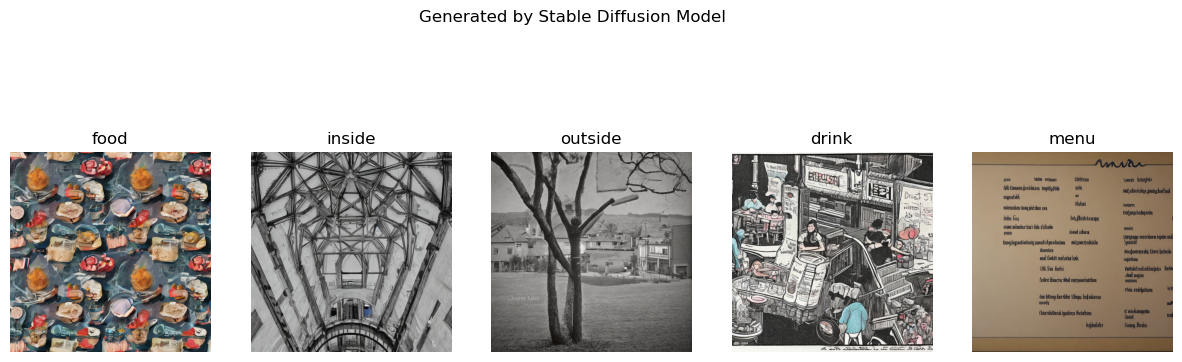

In [23]:
import torch
from diffusers import StableDiffusionPipeline  # Use StableDiffusionPipeline
import matplotlib.pyplot as plt

# Define the device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Stable Diffusion Model
ldm_pipe = StableDiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-2-1")

ldm_pipe.to(device)

# Labels to generate images for
labels = ["food", "inside", "outside", "drink", "menu"]

# Function to generate images
def generate_images(pipe, labels):
    generated_images = []
    for label in labels:
        print(f"Generating image for: {label}")
        image = pipe(prompt=label, num_inference_steps=50).images[0]  # Generate image
        generated_images.append(image)
    return generated_images

# Generate images using Stable Diffusion
ldm_images = generate_images(ldm_pipe, labels)

# Function to display images
def display_images(images, title="Stable Diffusion Model"):
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(labels[i])
    plt.suptitle(title)
    plt.show()

# Display images
display_images(ldm_images, "Generated by Stable Diffusion Model")


In [25]:
pip install torch-fidelity


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
pip install --upgrade torchmetrics


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
!pip uninstall torch-fidelity -y
!pip uninstall torchmetrics -y
!pip install torch-fidelity --no-cache-dir
!pip install torchmetrics[image] --no-cache-dir


Found existing installation: torch-fidelity 0.3.0
Uninstalling torch-fidelity-0.3.0:
  Successfully uninstalled torch-fidelity-0.3.0


Found existing installation: torchmetrics 1.7.0
Uninstalling torchmetrics-1.7.0:
  Successfully uninstalled torchmetrics-1.7.0



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/960.9 kB ? eta -:--:--
   - ------------------------------------- 30.7/960.9 kB 660.6 kB/s eta 0:00:02
   ------ --------------------------------- 163.8/960.9 kB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 960.9/960.9 kB 7.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import torch_fidelity
import torchmetrics.image.inception
print("Torch-Fidelity and TorchMetrics are installed correctly!")


Torch-Fidelity and TorchMetrics are installed correctly!


In [43]:
import torch
import numpy as np
from torchvision import models, transforms
from torch.nn import functional as F
from PIL import Image
import os
import matplotlib.pyplot as plt

# Load the pre-trained InceptionV3 model
inception_model = models.inception_v3(pretrained=True)
inception_model.eval()

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inception_model.to(device)

# Transformation to preprocess the images for InceptionV3
transform = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Function to calculate Inception Score
def calculate_inception_score(images, splits=10):
    predictions = []
    for img in images:
        img = transform(img).unsqueeze(0).to(device)  # Add batch dimension and move to device
        with torch.no_grad():
            pred = inception_model(img)
            pred_prob = F.softmax(pred, dim=1).cpu().numpy()  # Get the probability distribution
            predictions.append(pred_prob)
    
    predictions = np.concatenate(predictions, axis=0)
    
    # Compute marginal p(y)
    p_y = np.mean(predictions, axis=0)
    
    # Calculate the KL divergence
    kl_divergence = []
    for i in range(predictions.shape[0]):
        kl_divergence.append(np.sum(predictions[i] * (np.log(predictions[i]) - np.log(p_y))))
    
    kl_divergence = np.mean(kl_divergence)
    inception_score = np.exp(kl_divergence)
    
    return inception_score

# Step 1: Collect the generated images (ldm_images) from the Stable Diffusion generation function
# (Assuming 'ldm_images' is a list of generated images from the previous code block)

# Step 2: Calculate Inception Score
inception_score = calculate_inception_score(ldm_images)
print(f"Inception Score: {inception_score:.4f}")


Inception Score: 3.9557


In [46]:
import os

# Function to save already generated images to a folder
def save_generated_images(images, labels, save_folder):
    # Create the folder if it doesn't exist
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)
    
    # Save each image to the folder
    for i, img in enumerate(images):
        image_path = os.path.join(save_folder, f"{labels[i]}.png")  # Save each image as a .png file
        img.save(image_path)
        print(f"Saved: {image_path}")

# Folder where you want to save the generated images
generated_image_folder = r"C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Generated_Images"

# Save already generated images
save_generated_images(ldm_images, labels, generated_image_folder)

# Now, you can proceed with FID calculation on the generated images


Saved: C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Generated_Images\food.png
Saved: C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Generated_Images\inside.png
Saved: C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Generated_Images\outside.png
Saved: C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Generated_Images\drink.png
Saved: C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Generated_Images\menu.png


In [ ]:
import os
import torch
from torchvision import models, transforms
from PIL import Image, UnidentifiedImageError
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load the pre-trained InceptionV3 model
model = models.inception_v3(pretrained=True)
model.eval()

# Define image transformations
transform = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Define device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to extract features using InceptionV3 with error handling for invalid images
def extract_features(image_path):
    try:
        image = Image.open(image_path).convert('RGB')
        image = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device

        with torch.no_grad():
            features = model(image)  # Extract features from the image
        return features.cpu().numpy().flatten()
    
    except (UnidentifiedImageError, IOError) as e:
        print(f"Skipping invalid image {image_path}: {e}")
        return None  # Return None if the image is invalid

# Paths to the images
generated_image_folder = r"C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Generated_Images"  # Folder with generated images
large_image_folder = r"C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos"  # Folder with 200,000 images

# Function to filter out non-image files (valid extensions)
def is_valid_image(file_name):
    valid_image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
    return any(file_name.lower().endswith(ext) for ext in valid_image_extensions)

# Extract features for the generated images
generated_image_paths = [os.path.join(generated_image_folder, img) for img in os.listdir(generated_image_folder) if is_valid_image(img)]
generated_features = [extract_features(img) for img in generated_image_paths if extract_features(img) is not None]

# Extract features for the large dataset of images
large_image_paths = [os.path.join(large_image_folder, img) for img in os.listdir(large_image_folder) if is_valid_image(img)]
large_image_features = [extract_features(img) for img in large_image_paths if extract_features(img) is not None]

# Now compare the features of the generated images with the large dataset features
# Flatten all features into a single matrix
features_matrix = np.array(large_image_features)

# Calculate similarity between the generated images and the large dataset
similarity_scores = []
for generated_feature in generated_features:
    similarities = cosine_similarity([generated_feature], features_matrix)  # Compare each generated image to all the large images
    similarity_scores.append(similarities)

# Identify real images (those with lower similarity to generated images)
threshold = 0.5  # You can adjust this threshold based on your results
real_images = []

for idx, similarities in enumerate(similarity_scores):
    # If the similarity score is low, then it's more likely to be a real image
    if np.mean(similarities) < threshold:
        real_images.append(large_image_paths[idx])

# Now `real_images` contains the paths of images that are more likely to be real
print(f"Identified {len(real_images)} real images.")


Skipping invalid image C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\-BIybLxzoFt2d2zbYRcfHA.jpg: cannot identify image file 'C:\\Users\\ASUS\\OneDrive\\Documents\\Desktop\\Computer Vision\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\-BIybLxzoFt2d2zbYRcfHA.jpg'
Skipping invalid image C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\-NGY_19QK2zq913HdiYc5A.jpg: cannot identify image file 'C:\\Users\\ASUS\\OneDrive\\Documents\\Desktop\\Computer Vision\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\-NGY_19QK2zq913HdiYc5A.jpg'
Skipping invalid image C:\Users\ASUS\OneDrive\Documents\Desktop\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\-YAvSvGUs2ugiJUvIRO6Jw.jpg: cannot identify image file 'C:\\Users\\ASUS\\OneDrive\\Documents\\Desktop\\Computer Vision\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\-YAvSvGUs2ugiJUvIRO6Jw.jpg'
Skipping invalid image C:\Users\ASUS\OneDrive\

In [ ]:
import torch
import numpy as np
from scipy.linalg import sqrtm
from sklearn.metrics.pairwise import cosine_similarity

# Function to calculate FID
def calculate_fid(real_features, generated_features):
    # Calculate the mean and covariance of the real and generated features
    mu_real = np.mean(real_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    
    mu_gen = np.mean(generated_features, axis=0)
    sigma_gen = np.cov(generated_features, rowvar=False)

    # Calculate the Fréchet distance
    diff = mu_real - mu_gen
    covmean, _ = sqrtm(sigma_real.dot(sigma_gen), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma_real + sigma_gen - 2 * covmean)
    return fid

# Assuming `generated_features` and `large_image_features` are the feature arrays extracted earlier
real_features = np.array(large_image_features)
generated_features = np.array(generated_features)

# Calculate the FID score
fid_score = calculate_fid(real_features, generated_features)

print(f"FID score: {fid_score}")
